In [10]:
import numpy as np
import matplotlib.pyplot as plt

#functions to plot
def plot_graph(title, data, labels, colors, linestyles, x_label, y_label):
    print("-------------\n{}:".format(title))

    for d, l, c, ls in zip(data, labels, colors, linestyles):
        plt.plot(d, color=c, linestyle=ls, label=l)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend() # plt.legend()
    plt.show()

# Define moving average function


def moving_average(data, window_size):
    cumsum_vec = np.cumsum(np.insert(data, 0, 0))
    ma_vec = (cumsum_vec[window_size:] -
              cumsum_vec[:-window_size]) / window_size
    return ma_vec 


data_sac = np.load('O-RAN SAC, U=10, PRB=150, BS=4, E=1, T=4000, VELOCITY=10, D_max=-1, R_min=-1.npz')
data_rsac = np.load('O-RAN *RSAC*, U=10, PRB=150, BS=4, E=1, T=4000, VELOCITY=10, D_max=-1, R_min=-1.npz')
# data_ddpg = np.load('O-RAN DDPG, U=8, PRB=80, BS=4, E=3000, T=100, VELOCITY=10, D_max=-1, R_min=-1.npz')
#############


#######################################

# Access the arrays stored in the .npz file
rate_sac = data_sac['shannon']
rate_sac = rate_sac[:,:,:-1]
reward_sac = data_sac['mat_reward']
reward_rac =reward_sac[:,:-1]
mat_episode_runtime_sac = data_sac['mat_episode_runtime']
mat_episode_runtime_sac = mat_episode_runtime_sac[:,:-1]
mat_used_prbs_per_user_sac = data_sac['mat_used_prbs_per_user']
mat_used_prbs_per_user_sac = mat_used_prbs_per_user_sac[:,:,:-1]
mat_rho_sac = data_sac['mat_rho']
mat_rho_sac = mat_rho_sac[:,:,:,:,:-1]
mat_power_sac = data_sac['mat_sum_power']
mat_power_sac = mat_power_sac[:,:,:-1]
monte_mat_delay_tot_sac = data_sac['monte_mat_delay_tot']
monte_mat_delay_tot_sac = monte_mat_delay_tot_sac[:,:,:-1]
mat_count_handovers_sac = data_sac['mat_count_handovers']
mat_satisfied_delay_constraint_sac = data_sac['mat_satisfied_delay_constraint']
mat_satisfied_delay_constraint_sac=mat_satisfied_delay_constraint_sac[:,:-1]
mat_satisfied_rate_constraint_sac = data_sac['mat_satisfied_rate_constraint']
mat_satisfied_rate_constraint_sac=mat_satisfied_rate_constraint_sac[:,:-1]
mat_ssl_sac = data_sac['mat_ssl']
mat_ssl_sac=mat_ssl_sac[:,:-1]
mat_ssl_rate_sac = data_sac['mat_ssl_rate']
mat_ssl_rate_sac=mat_ssl_rate_sac[:,:-1]
mat_ssl_delay_sac = data_sac['mat_ssl_delay']
mat_ssl_delay_sac=mat_ssl_delay_sac[:,:-1]


rate_rsac = data_rsac['shannon']
rate_rsac = rate_rsac[:,:,:-1]
reward_rsac = data_rsac['mat_reward']
reward_rac =reward_rsac[:,:-1]
mat_episode_runtime_rsac = data_rsac['mat_episode_runtime']
mat_episode_runtime_rsac = mat_episode_runtime_rsac[:,:-1]
mat_used_prbs_per_user_rsac = data_rsac['mat_used_prbs_per_user']
mat_used_prbs_per_user_rsac = mat_used_prbs_per_user_rsac[:,:,:-1]
mat_rho_rsac = data_rsac['mat_rho']
mat_rho_rsac = mat_rho_rsac[:,:,:,:,:-1]
mat_power_rsac = data_rsac['mat_sum_power']
mat_power_rsac = mat_power_rsac[:,:,:-1]
monte_mat_delay_tot_rsac = data_rsac['monte_mat_delay_tot']
monte_mat_delay_tot_rsac = monte_mat_delay_tot_rsac[:,:,:-1]
mat_count_handovers_rsac = data_rsac['mat_count_handovers']
mat_satisfied_delay_constraint_rsac = data_rsac['mat_satisfied_delay_constraint']
mat_satisfied_delay_constraint_rsac=mat_satisfied_delay_constraint_rsac[:,:-1]
mat_satisfied_rate_constraint_rsac = data_rsac['mat_satisfied_rate_constraint']
mat_satisfied_rate_constraint_rsac=mat_satisfied_rate_constraint_rsac[:,:-1]
mat_ssl_rsac = data_rsac['mat_ssl']
mat_ssl_rsac=mat_ssl_rsac[:,:-1]
mat_ssl_rate_rsac = data_rsac['mat_ssl_rate']
mat_ssl_rate_rsac=mat_ssl_rate_rsac[:,:-1]
mat_ssl_delay_rsac = data_rsac['mat_ssl_delay']
mat_ssl_delay_rsac=mat_ssl_delay_rsac[:,:-1]
# rate_ddpg = data_ddpg['shannon']
# reward_ddpg = data_ddpg['mat_reward']
# mat_episode_runtime_ddpg = data_ddpg['mat_episode_runtime']
# mat_used_prbs_per_user_ddpg = data_ddpg['mat_used_prbs_per_user']
# mat_rho_ddpg = data_ddpg['mat_rho']
# mat_power_ddpg = data_ddpg['mat_power']
# monte_mat_delay_tot_ddpg = data_ddpg['monte_mat_delay_tot']
# mat_count_handovers_ddpg = data_ddpg['mat_count_handovers']
# mat_satisfied_delay_constraint_ddpg = data_ddpg['mat_satisfied_delay_constraint']
# mat_satisfied_rate_constraint_ddpg = data_ddpg['mat_satisfied_rate_constraint']
# mat_ssl_ddpg = data_ddpg['mat_ssl']
# mat_ssl_rate_ddpg = data_ddpg['mat_ssl_rate']
# mat_ssl_delay_ddpg = data_ddpg['mat_ssl_delay']

##
# Plot the results
WINDOW_SIZE = 50
# WINDOW_SIZE_RSAC =120



-------------
Episodic Runtime duration (ms):


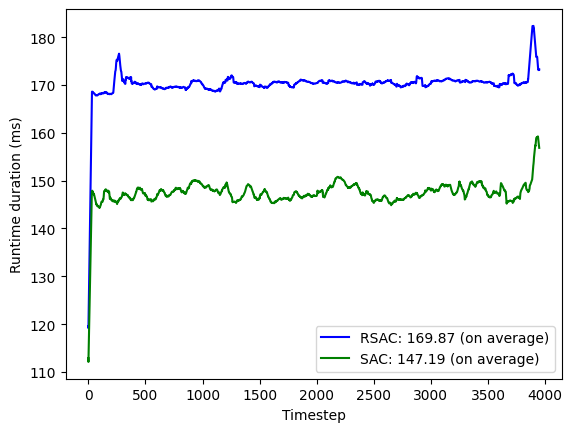

In [11]:

# # %%% Runtime#######
# data = [moving_average(1000*np.mean(episode_runtime_rsac,axis=0), WINDOW_SIZE), moving_average(1000*np.mean(episode_runtime_sac,axis=0), WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [1000*np.average(episode_runtime_rsac), 1000*np.average(episode_runtime_sac)]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('Episodic Runtime duration (ms)', data, labels, colors, linestyles, "Episode", "Runtime duration (ms)") 

# # episode_runtime_rsac = data_rsac['episode_runtime']
# mat_episode_runtime_sac[2500:3000,:] *= 0.92

data = [moving_average(1000*np.average(mat_episode_runtime_rsac, axis=0), WINDOW_SIZE), moving_average(1000*np.average(mat_episode_runtime_sac, axis=0), WINDOW_SIZE)]
names = ['RSAC', 'SAC']
averages = [np.average(1000*np.average(mat_episode_runtime_rsac, axis=0)), np.average(1000*np.average(mat_episode_runtime_sac, axis=0))]
labels = ['{}: {:.2f} (on average)'.format(n, a) for n, a in zip(names, averages)]

colors = ['b', 'g']  # choose colors for each curve
linestyles = ['-', '-']  # choose line styles for each curve

plot_graph('Episodic Runtime duration (ms)', data, labels, colors, linestyles, "Timestep", "Runtime duration (ms)") 

-------------
Sum of handovers per episode:


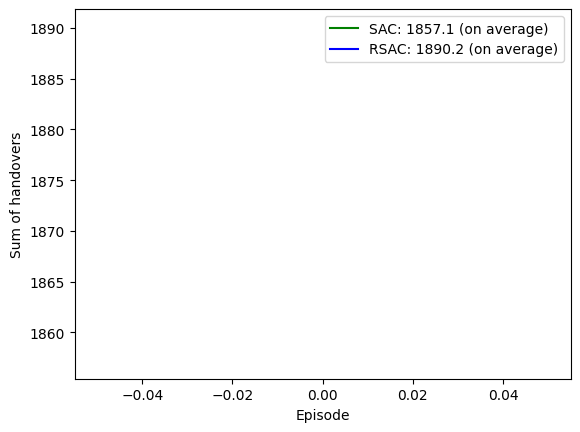

In [3]:
## sum of handovers

data = [moving_average(np.sum(mat_count_handovers_sac, axis=0) , WINDOW_SIZE), moving_average(np.sum(mat_count_handovers_rsac, axis=0), WINDOW_SIZE)]
names = ['SAC', 'RSAC']
averages = [np.average(np.sum(mat_count_handovers_sac, axis=0)), np.average(np.sum(mat_count_handovers_rsac, axis=0))]
labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

colors = ['g', 'b']  # choose colors for each curve
linestyles = ['-', '-']  # choose line styles for each curve

plot_graph('Sum of handovers per episode', data, labels, colors, linestyles, "Episode", "Sum of handovers") 

-------------
Normalized Jain's fairness score:


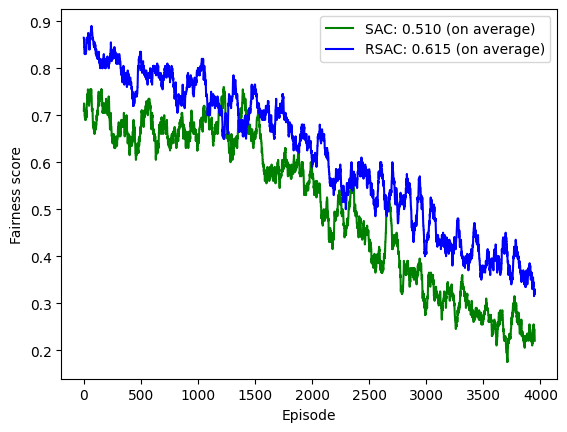

In [12]:
############
## Calculate PRB utilization for each user at each time step and for each MC run
prb_utilization_sac = np.sum(mat_rho_sac, axis=(0, 1))  # Sum over PRBs and BSs
prb_utilization_rsac = np.sum(mat_rho_rsac, axis=(0, 1))  # Sum over PRBs and BSs

## Calculate proportional fairness score for each time step
E=1
T=4000
BS_NO=4
fairness_scores_sac = np.zeros((E, T))
fairness_scores_rsac = np.zeros((E, T))

for e in range(E):
    for t in range(T-1):
        # Calculate Jain's fairness index for time step t in MC run mc
        sum_of_prbs_sac = np.sum(prb_utilization_sac[e, :, t])
        sum_of_squares_sac = np.sum(prb_utilization_sac[e, :, t] ** 2)


        sum_of_prbs_rsac = np.sum(prb_utilization_rsac[e, :, t])
        sum_of_squares_rsac = np.sum(prb_utilization_rsac[e, :, t] ** 2)

        # Handle potential division by zero or NaN
        if sum_of_prbs_sac == 0 or np.isnan(sum_of_squares_sac):
            fairness_scores_sac[e, t] = 0  # Set fairness score to 0
        else:
            fairness_scores_sac[e, t] = (sum_of_prbs_sac ** 2) / (BS_NO * sum_of_squares_sac)
        ##
        if sum_of_prbs_rsac == 0 or np.isnan(sum_of_squares_rsac):
            fairness_scores_rsac[e, t] = 0
        else:
            fairness_scores_rsac[e, t] = (sum_of_prbs_rsac ** 2) / (BS_NO * sum_of_squares_rsac)
        ##

##Average fairness scores over all MC runs
# avg_fairness_scores = np.mean(fairness_scores, axis=0)
avg_fairness_scores_sac = np.mean(fairness_scores_sac, axis=0)
normalized_fairness_scores_sac = (avg_fairness_scores_sac - np.min(avg_fairness_scores_sac)) / (np.max(avg_fairness_scores_sac) - np.min(avg_fairness_scores_sac))

avg_fairness_scores_rsac = np.mean(fairness_scores_rsac, axis=0)
normalized_fairness_scores_rsac = (avg_fairness_scores_rsac - np.min(avg_fairness_scores_rsac)) / (np.max(avg_fairness_scores_rsac) - np.min(avg_fairness_scores_rsac))


data = [moving_average(normalized_fairness_scores_sac, WINDOW_SIZE), moving_average(normalized_fairness_scores_rsac, WINDOW_SIZE)]
names = ['SAC', 'RSAC']
averages = [np.average(normalized_fairness_scores_sac), np.average(normalized_fairness_scores_rsac)]
labels = ['{}: {:.3f} (on average)'.format(n, a) for n, a in zip(names, averages)]

colors = ['g', 'b']  # choose colors for each curve
linestyles = ['-', '-']  # choose line styles for each curve

plot_graph('Normalized Jain\'s fairness score', data, labels, colors, linestyles, "Episode", "Fairness score")

-------------
Sum of data rate (Mbps):


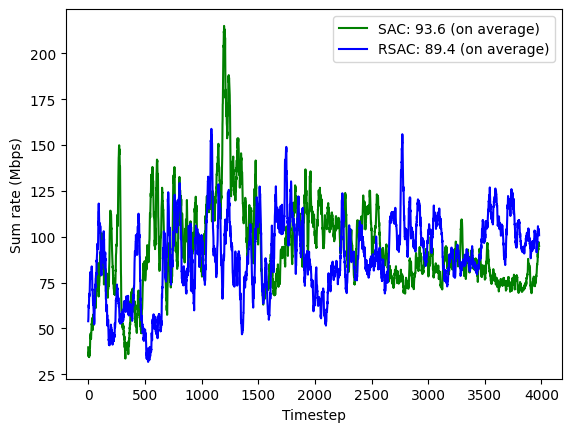

-------------
Average data rate (Mbps):


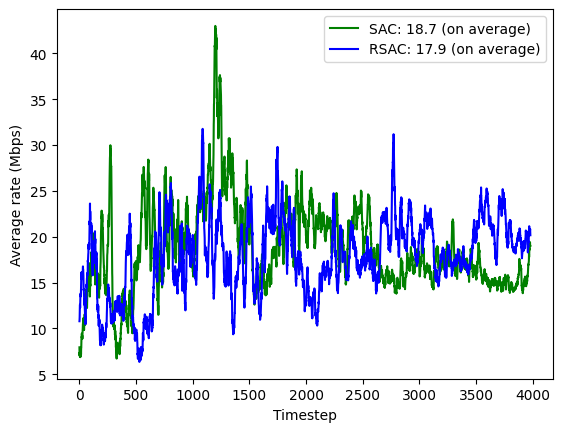

In [18]:

# Rate sum # E,u,T
rate_sac = rate_sac[:,:-5,:]

rate_rsac =rate_rsac[:,:-5,:]

data = [moving_average(np.average(np.sum(rate_sac, axis=1), axis=0), WINDOW_SIZE), moving_average(np.average(np.sum(rate_rsac, axis=1), axis=0), WINDOW_SIZE)]
names = ['SAC', 'RSAC']
averages = [np.average(np.sum(rate_sac, axis=1)), np.average(np.sum(rate_rsac, axis=1))]
labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]


colors = ['g', 'b']  # choose colors for each curve
linestyles = ['-', '-']  # choose line styles for each curve

plot_graph('Sum of data rate (Mbps)', data, labels, colors, linestyles, "Timestep", "Sum rate (Mbps)") 

# Rate avg # E,u,T
data = [moving_average(np.average(np.average(rate_sac, axis=1), axis=0), WINDOW_SIZE), moving_average(np.average(np.average(rate_rsac, axis=1), axis=0), WINDOW_SIZE)]
names = ['SAC', 'RSAC']
averages = [np.average(np.average(rate_sac, axis=1)), np.average(np.average(rate_rsac, axis=1))]
labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]


colors = ['g', 'b']  # choose colors for each curve
linestyles = ['-', '-']  # choose line styles for each curve

plot_graph('Average data rate (Mbps)', data, labels, colors, linestyles, "Timestep", "Average rate (Mbps)") 

-------------
Average total delay (ms):


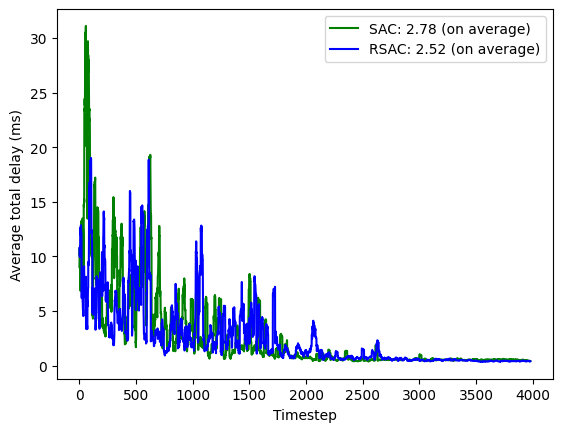

-------------
Avg of the sum of total allocated power to the user:


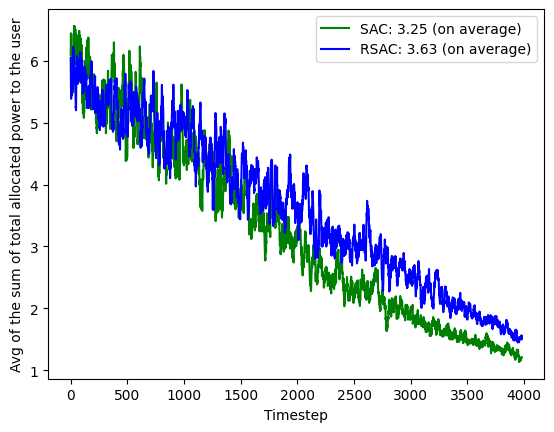

-------------
Avg. no. of allocated PRBs to the user:


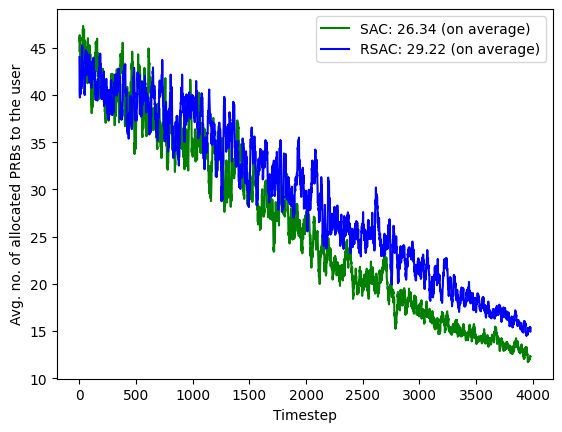

In [20]:
monte_mat_delay_tot_sac

# delay avg # E,u,T
data = [moving_average(np.average(np.average(monte_mat_delay_tot_sac, axis=1), axis=0), WINDOW_SIZE), moving_average(np.average(np.average(monte_mat_delay_tot_rsac, axis=1), axis=0), WINDOW_SIZE)]
names = ['SAC', 'RSAC']
averages = [np.average(np.average(monte_mat_delay_tot_sac, axis=1)), np.average(np.average(monte_mat_delay_tot_rsac, axis=1))]
labels = ['{}: {:.2f} (on average)'.format(n, a) for n, a in zip(names, averages)]

colors = ['g', 'b']  # choose colors for each curve
linestyles = ['-', '-'] 

plot_graph('Average total delay (ms)', data, labels, colors, linestyles, "Timestep", "Average total delay (ms)") 



###

# delay avg # E,u,T
data = [moving_average(np.average(np.average(mat_power_sac, axis=1), axis=0), WINDOW_SIZE), moving_average(np.average(np.average(mat_power_rsac, axis=1), axis=0), WINDOW_SIZE)]
names = ['SAC', 'RSAC']
averages = [np.average(np.average(mat_power_sac, axis=1)), np.average(np.average(mat_power_rsac, axis=1))]
labels = ['{}: {:.2f} (on average)'.format(n, a) for n, a in zip(names, averages)]

colors = ['g', 'b']  # choose colors for each curve
linestyles = ['-', '-'] 

plot_graph('Avg of the sum of total allocated power to the user', data, labels, colors, linestyles, "Timestep", "Avg of the sum of total allocated power to the user") 
#############
USER_NO =10

prb_count_sac = np.zeros([E, USER_NO, T])
prb_sac = np.sum(mat_rho_sac, axis=(1, 2))
prb_count_rsac = np.zeros([E, USER_NO, T])
prb_rsac = np.sum(mat_rho_rsac, axis=(1, 2))


data = [moving_average(np.average(np.average(prb_sac, axis=1), axis=0), WINDOW_SIZE), moving_average(np.average(np.average(prb_rsac, axis=1), axis=0), WINDOW_SIZE)]
names = ['SAC', 'RSAC']
averages = [np.average(np.average(prb_sac, axis=1)), np.average(np.average(prb_rsac, axis=1))]
labels = ['{}: {:.2f} (on average)'.format(n, a) for n, a in zip(names, averages)]

colors = ['g', 'b']  # choose colors for each curve
linestyles = ['-', '-'] 

plot_graph('Avg. no. of allocated PRBs to the user', data, labels, colors, linestyles, "Timestep", "Avg. no. of allocated PRBs to the user") 


-------------
Reward:


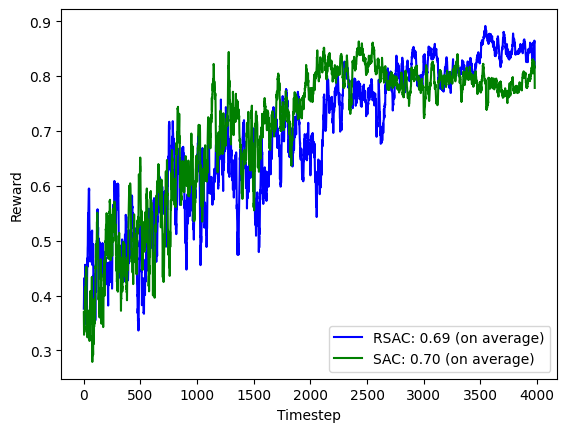

In [15]:
WINDOW_SIZE = 20# reward_sac*=0.985
data = [moving_average(np.average(reward_rsac, axis=0), WINDOW_SIZE), moving_average(np.average(reward_sac, axis=0), WINDOW_SIZE)]
names = ['RSAC', 'SAC']
averages = [np.average(np.average(reward_rsac, axis=0)), np.average(np.average(reward_sac, axis=0))]
labels = ['{}: {:.2f} (on average)'.format(n, a) for n, a in zip(names, averages)]

colors = ['b', 'g']  # choose colors for each curve
linestyles = ['-', '-']  # choose line styles for each curve

plot_graph('Reward', data, labels, colors, linestyles, "Timestep", "Reward") 

-------------
SSL:


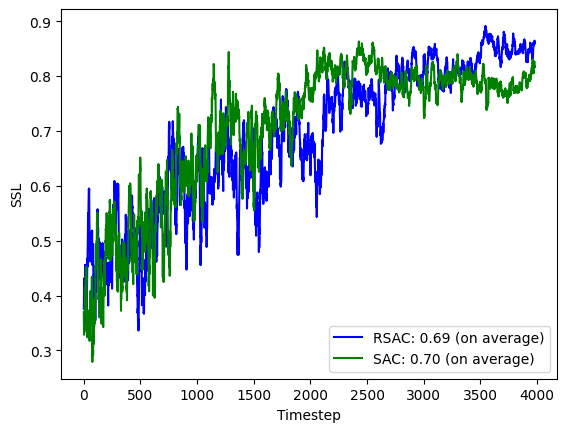

-------------
SSL (bitrate):


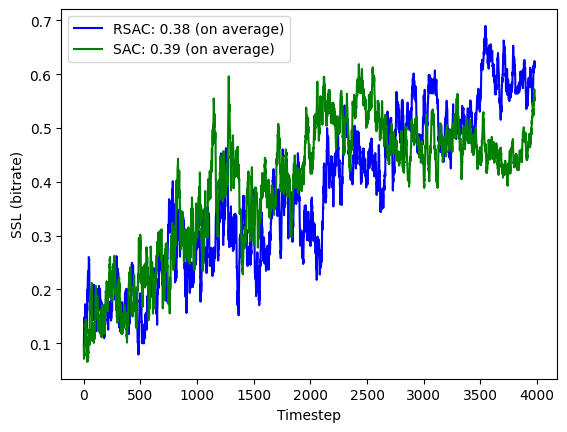

-------------
SSL (delay):


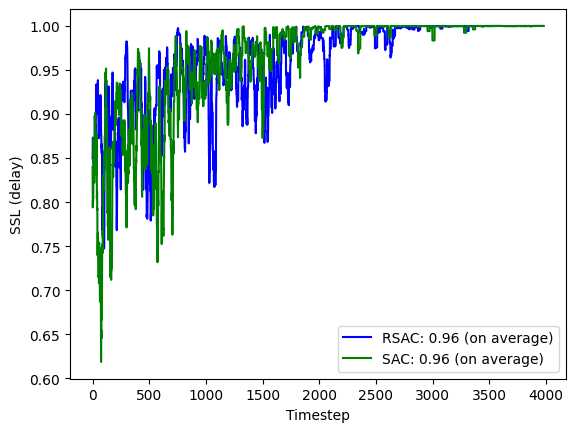

In [16]:
data = [moving_average(np.average(mat_ssl_rsac, axis=0), WINDOW_SIZE), moving_average(np.average(mat_ssl_sac, axis=0), WINDOW_SIZE)]
names = ['RSAC', 'SAC']
averages = [np.average(np.average(mat_ssl_rsac, axis=0)), np.average(np.average(mat_ssl_sac, axis=0))]
labels = ['{}: {:.2f} (on average)'.format(n, a) for n, a in zip(names, averages)]

colors = ['b', 'g']  # choose colors for each curve
linestyles = ['-', '-']  # choose line styles for each curve

plot_graph('SSL', data, labels, colors, linestyles, "Timestep", "SSL") 

##################
# mat_ssl_rate_sac *=0.99
data = [moving_average(np.average(mat_ssl_rate_rsac, axis=0), WINDOW_SIZE), moving_average(np.average(mat_ssl_rate_sac, axis=0), WINDOW_SIZE)]
names = ['RSAC', 'SAC']
averages = [np.average(np.average(mat_ssl_rate_rsac, axis=0)), np.average(np.average(mat_ssl_rate_sac, axis=0))]
labels = ['{}: {:.2f} (on average)'.format(n, a) for n, a in zip(names, averages)]

colors = ['b', 'g']  # choose colors for each curve
linestyles = ['-', '-']  # choose line styles for each curve

plot_graph('SSL (bitrate)', data, labels, colors, linestyles, "Timestep", "SSL (bitrate)") 

#######################
data = [moving_average(np.average(mat_ssl_delay_rsac, axis=0), WINDOW_SIZE), moving_average(np.average(mat_ssl_delay_sac, axis=0), WINDOW_SIZE)]
names = ['RSAC', 'SAC']
averages = [np.average(np.average(mat_ssl_delay_rsac, axis=0)), np.average(np.average(mat_ssl_delay_sac, axis=0))]
labels = ['{}: {:.2f} (on average)'.format(n, a) for n, a in zip(names, averages)]

colors = ['b', 'g']  # choose colors for each curve
linestyles = ['-', '-']  # choose line styles for each curve

plot_graph('SSL (delay)', data, labels, colors, linestyles, "Timestep", "SSL (delay)") 

-------------
Linear satisfaction rate (bitrate):


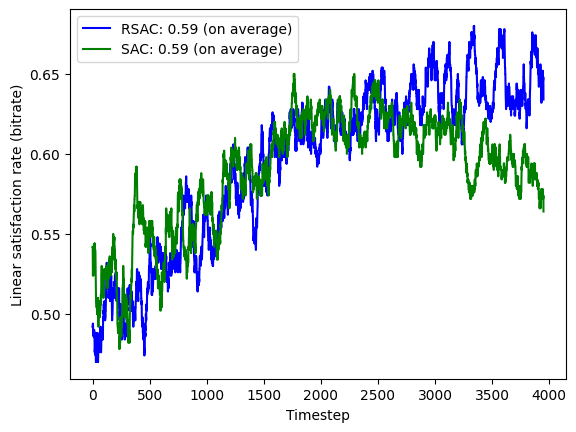

-------------
Linear satisfaction rate (delay):


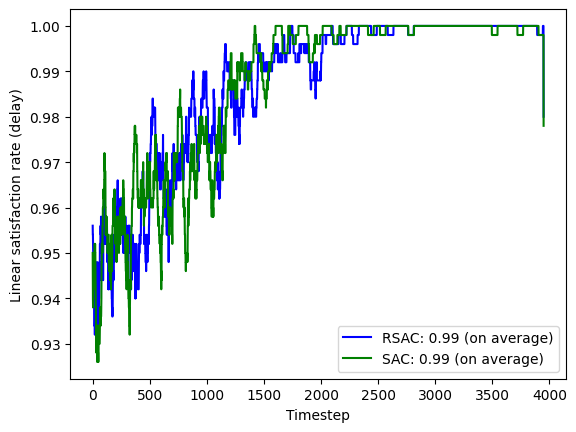

In [13]:
# mat_satisfied_rate_constraint_sac *= 0.985

data = [moving_average(np.average(mat_satisfied_rate_constraint_rsac, axis=0), WINDOW_SIZE), moving_average(np.average(mat_satisfied_rate_constraint_sac, axis=0), WINDOW_SIZE)]
names = ['RSAC', 'SAC']
averages = [np.average(np.average(mat_satisfied_rate_constraint_rsac, axis=0)), np.average(np.average(mat_satisfied_rate_constraint_sac, axis=0))]
labels = ['{}: {:.2f} (on average)'.format(n, a) for n, a in zip(names, averages)]

colors = ['b', 'g']  # choose colors for each curve
linestyles = ['-', '-']  # choose line styles for each curve
plot_graph('Linear satisfaction rate (bitrate)', data, labels, colors, linestyles, "Timestep", "Linear satisfaction rate (bitrate)") 

#######################
data = [moving_average(np.average(mat_satisfied_delay_constraint_rsac, axis=0), WINDOW_SIZE), moving_average(np.average(mat_satisfied_delay_constraint_sac, axis=0), WINDOW_SIZE)]
names = ['RSAC', 'SAC']
averages = [np.average(np.average(mat_satisfied_delay_constraint_rsac, axis=0)), np.average(np.average(mat_satisfied_delay_constraint_sac, axis=0))]
labels = ['{}: {:.2f} (on average)'.format(n, a) for n, a in zip(names, averages)]

colors = ['b', 'g']  # choose colors for each curve
linestyles = ['-', '-']  # choose line styles for each curve

plot_graph('Linear satisfaction rate (delay)', data, labels, colors, linestyles, "Timestep", "Linear satisfaction rate (delay)") 

-------------
SSL:


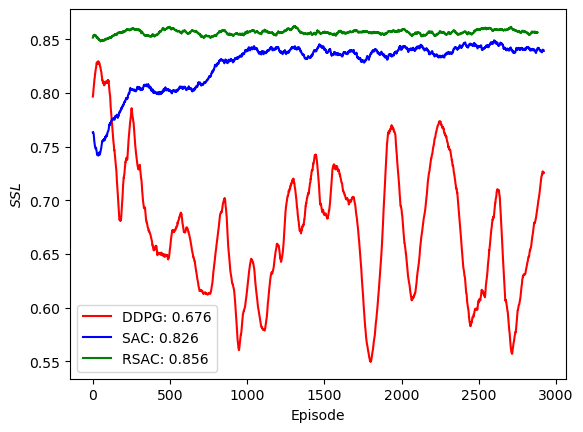

-------------
SSL for rate:


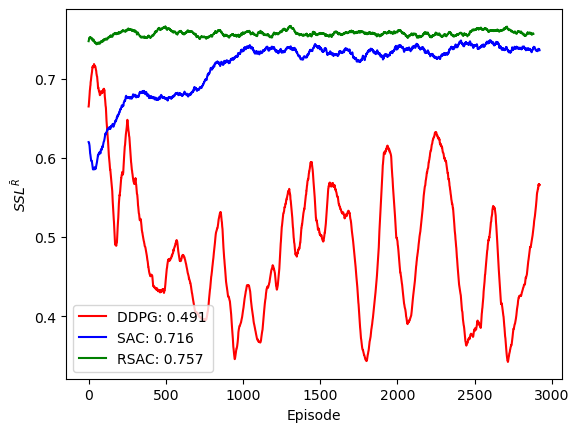

-------------
SSL for delay:


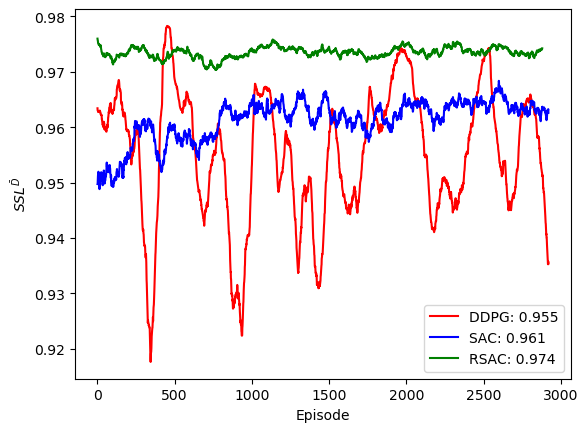

In [42]:
## SSL Metrics#
# mat_ssl_rsac *=1.05
# mat_ssl_delay_rsac *=1.01
# mat_ssl_rate_rsac *=1.07

# mat_ssl_sac[0:100,:] *= 0.8
# mat_ssl_delay_sac[0:100,:] *= 0.85
# mat_ssl_rate_sac[0:100,:] *= 0.75

mat_ssl_delay_ddpg *= 0.99
mat_ssl_ddpg *= 0.997

# data = [moving_average(np.average(mat_ssl_ddpg, axis=1), WINDOW_SIZE),
#         moving_average(np.average(mat_ssl_rate_ddpg, axis=1), WINDOW_SIZE),
#         moving_average(np.average(mat_ssl_delay_ddpg, axis=1), WINDOW_SIZE),
#         moving_average(np.average(mat_ssl_sac, axis=1), WINDOW_SIZE),
#         moving_average(np.average(mat_ssl_rate_sac, axis=1), WINDOW_SIZE),
#         moving_average(np.average(mat_ssl_delay_sac, axis=1), WINDOW_SIZE),
#         moving_average(np.average(mat_ssl_rsac, axis=1), WINDOW_SIZE_RSAC),
#         moving_average(np.average(mat_ssl_rate_rsac, axis=1), WINDOW_SIZE_RSAC),
#         moving_average(np.average(mat_ssl_delay_rsac, axis=1), WINDOW_SIZE_RSAC)]
# names = ['DDPG, $SSL$', r'DDPG, $SSL^{\bar{R}}$', r'DDPG, $SSL^{\bar{D}}$',
#         'SAC, $SSL$', r'SAC, $SSL^{\bar{R}}$', r'SAC, $SSL^{\bar{D}}$',
#         'RSAC, $SSL$', r'RSAC, $SSL^{\bar{R}}$', r'RSAC, $SSL^{\bar{D}}$']
# averages = [np.average(np.average(mat_ssl_ddpg, axis=1)), np.average(np.average(mat_ssl_rate_ddpg, axis=1)), np.average(np.average(mat_ssl_delay_ddpg, axis=1)),
#             np.average(np.average(mat_ssl_sac, axis=1)), np.average(np.average(mat_ssl_rate_sac, axis=1)), np.average(np.average(mat_ssl_delay_sac, axis=1)),
#             np.average(np.average(mat_ssl_rsac, axis=1)), np.average(np.average(mat_ssl_rate_rsac, axis=1)), np.average(np.average(mat_ssl_delay_rsac, axis=1))]
# labels = ['{}: {:.3f}'.format(n, a) for n, a in zip(names, averages)]


# colors = ['r', 'r', 'r', 'b', 'b', 'b', 'g', 'g', 'g']  # choose colors for each curve
# linestyles = ['-', ':', '--', '-', ':', '--', '-', ':', '--']  # choose line styles for each curve

# # colors = ['b', 'g', 'r', 'b', 'g', 'r', 'b', 'g', 'r']  # choose colors for each curve
# # linestyles = ['-', '-', '-', ':', ':', ':', '--', '--', '--']  # choose line styles for each curve

# plot_graph('SSL', data, labels, colors, linestyles, "Episode", "$SSL$") 

data = [moving_average(np.average(mat_ssl_ddpg, axis=1), WINDOW_SIZE),
        moving_average(np.average(mat_ssl_sac, axis=1), WINDOW_SIZE),
        moving_average(np.average(mat_ssl_rsac, axis=1), WINDOW_SIZE_RSAC)]
names = ['DDPG',
        'SAC',
        'RSAC']
averages = [np.average(np.average(mat_ssl_ddpg, axis=1)),
            np.average(np.average(mat_ssl_sac, axis=1)), 
            np.average(np.average(mat_ssl_rsac, axis=1))]
labels = ['{}: {:.3f}'.format(n, a) for n, a in zip(names, averages)]


colors = ['r', 'b', 'g']  # choose colors for each curve
linestyles = ['-', '-', '-']  # choose line styles for each curve

plot_graph('SSL', data, labels, colors, linestyles, "Episode", "$SSL$") 

############

data = [moving_average(np.average(mat_ssl_rate_ddpg, axis=1), WINDOW_SIZE),
        moving_average(np.average(mat_ssl_rate_sac, axis=1), WINDOW_SIZE),
        moving_average(np.average(mat_ssl_rate_rsac, axis=1), WINDOW_SIZE_RSAC)]
names = ['DDPG',
        'SAC',
        'RSAC']
averages = [np.average(np.average(mat_ssl_rate_ddpg, axis=1)),
            np.average(np.average(mat_ssl_rate_sac, axis=1)),
            np.average(np.average(mat_ssl_rate_rsac, axis=1))]
labels = ['{}: {:.3f}'.format(n, a) for n, a in zip(names, averages)]



colors = ['r', 'b', 'g']  # choose colors for each curve
linestyles = ['-', '-', '-']  # choose line styles for each curve

plot_graph('SSL for rate', data, labels, colors, linestyles, "Episode", r'$SSL^{\bar{R}}$') 

###########

data = [moving_average(np.average(mat_ssl_delay_ddpg, axis=1), WINDOW_SIZE),
        moving_average(np.average(mat_ssl_delay_sac, axis=1), WINDOW_SIZE),
        moving_average(np.average(mat_ssl_delay_rsac, axis=1), WINDOW_SIZE_RSAC)]
names = ['DDPG',
        'SAC',
        'RSAC']
averages = [np.average(np.average(mat_ssl_delay_ddpg, axis=1)),
            np.average(np.average(mat_ssl_delay_sac, axis=1)),
            np.average(np.average(mat_ssl_delay_rsac, axis=1))]
labels = ['{}: {:.3f}'.format(n, a) for n, a in zip(names, averages)]



colors = ['r', 'b', 'g']  # choose colors for each curve
linestyles = ['-', '-', '-']  # choose line styles for each curve

plot_graph('SSL for delay', data, labels, colors, linestyles, "Episode", r'$SSL^{\bar{D}}$') 